In [129]:
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [130]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [131]:
data_path = "/content/drive/MyDrive/College Homework/BME450/BME450-MRINeurologicalDiseaseClassification/RareNeuroReduced"

In [132]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

training_data = datasets.ImageFolder(
    root=os.path.join(data_path, "Train"),
    transform=transform
    )

validation_data = datasets.ImageFolder(
    root=os.path.join(data_path, "Val"),
    transform=transform
    )

test_data = datasets.ImageFolder(
    root=os.path.join(data_path, "Test"),
    transform=transform
    )

categories = training_data.classes
#categories = ['fukuyama_muscular_dystrophy', 'hallervorden_spatz_disease', 'moyamoya_disease', 'pachygyria_cerebellar_hypoplasia', 'walker_warburg_syndrome']

In [134]:
# Neuron Definitions
class Net(nn.Module):
    def __init__(self):
      super(Net, self).__init__()
      self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
      in_features = self.model.fc.in_features
      self.model.fc = nn.Linear(in_features, 5)

    def forward(self, x):
      return self.model(x)

# Trains system
def train_loop(dataloader, model, loss_fn, optimizer):
    total_loss = 0
    num_batches = len(dataloader)

    for X, y in dataloader:
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / num_batches

# Tests system
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    correct = 0
    total_loss = 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            total_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / size

    return avg_loss, accuracy

Train dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7a958216a8a0>
Test dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7a95a47eb500>
Epoch 1
-------------------------------
Train Loss: 1.8770
Val Loss: 1.5651, Accuracy: 38.7%

Epoch 2
-------------------------------
Train Loss: 1.2981
Val Loss: 1.3546, Accuracy: 60.0%

Epoch 3
-------------------------------
Train Loss: 1.0508
Val Loss: 1.2350, Accuracy: 65.3%

Epoch 4
-------------------------------
Train Loss: 0.8929
Val Loss: 1.1540, Accuracy: 70.7%

Epoch 5
-------------------------------
Train Loss: 0.7754
Val Loss: 1.1011, Accuracy: 72.0%

Epoch 6
-------------------------------
Train Loss: 0.6826
Val Loss: 1.0514, Accuracy: 72.0%

Epoch 7
-------------------------------
Train Loss: 0.6124
Val Loss: 1.0391, Accuracy: 73.3%

Epoch 8
-------------------------------
Train Loss: 0.5826
Val Loss: 1.0006, Accuracy: 73.3%

Epoch 9
-------------------------------
Train Loss: 0.5939
Val Loss: 1.0483, Accu

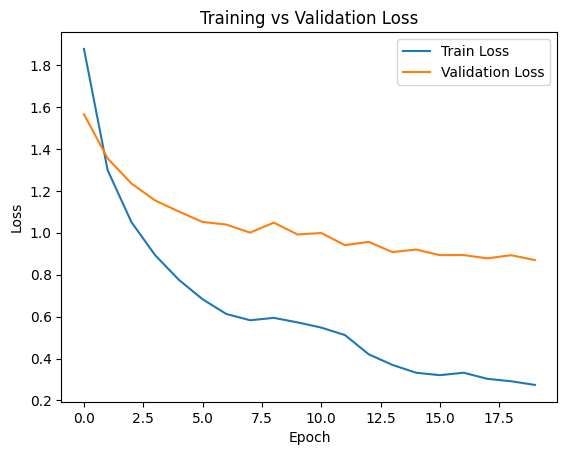

In [135]:
# Training
train_losses = []
val_losses = []
val_accuracies = []

model = Net()

# ResNet Model
for param in model.model.parameters():
    param.requires_grad = False
for param in model.model.layer4.parameters():
    param.requires_grad = True
for param in model.model.fc.parameters():
    param.requires_grad = True

batch_size = 32
train_dataloader = DataLoader(training_data, batch_size=batch_size)
val_dataloader = DataLoader(validation_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)
print('Train dataloader:', train_dataloader)
print('Test dataloader:', test_dataloader)

loss_fn = nn.CrossEntropyLoss() # used for categorization
learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epochs = 20
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    val_loss, val_accuracy = test_loop(val_dataloader, model, loss_fn)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Accuracy: {val_accuracy*100:.1f}%\n")

print("Done!")

test_loss, test_accuracy = test_loop(test_dataloader, model, loss_fn)
print(f"Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_accuracy*100:.1f}%\n")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

<Figure size 800x800 with 0 Axes>

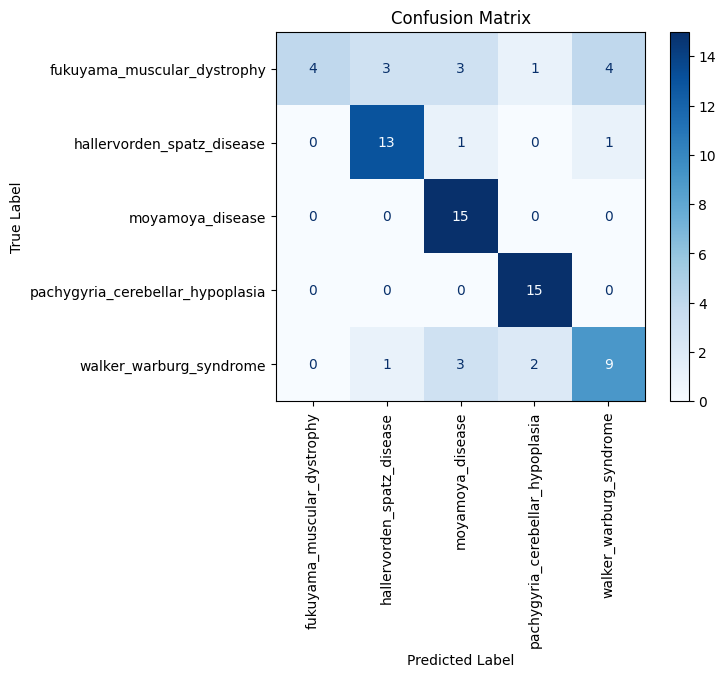

In [137]:
# Confusion Matrix

model.eval()

def get_predictions(model, dataloader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in dataloader:
            outputs = model(X)
            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# Get predictions on test set
y_true, y_pred = get_predictions(model, test_dataloader)

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=training_data.classes
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", xticks_rotation=90)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()